<a href="https://colab.research.google.com/github/tanishqua-02/tanishqua-02/blob/main/Data%20Science%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ydata-profiling sweetviz openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Load the Excel file
file_path ="/content/Banking_Transactions_Customer_Profiling_Project.xlsx"
df = pd.read_excel(file_path)

df.head()
import pandas as pd
import pandas_profiling
import sweetviz as sv
import re

# Read all sheets
customers = pd.read_excel(file_path, sheet_name="customers")
accounts = pd.read_excel(file_path, sheet_name="accounts")
transactions = pd.read_excel(file_path, sheet_name="transactions")
cards = pd.read_excel(file_path, sheet_name="cards")
branches = pd.read_excel(file_path, sheet_name="branches")
employees = pd.read_excel(file_path, sheet_name="employees")

print(customers.head())
print(accounts.head())
print(transactions.head())


/tmp/ipython-input-3508941268.py:9: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


  customer_id              name        dob  gender  \
0      C10000       Tina Wilson 1978-06-05    Male   
1      C10001  Jennifer Johnson 1946-11-21    Male   
2      C10002    Ellen Williams 1965-04-17   Other   
3      C10003    Joshua Sanchez 1950-03-18  Female   
4      C10004   Sandra Gonzales 1994-11-07  Female   

                            email                 phone  \
0  qjacobson@barajas-matthews.org          323.869.3246   
1               eturner@yahoo.com   (404)585-6821x62304   
2                 qbrown@wade.com  001-661-628-7887x779   
3         cortezjessica@gmail.com    (103)714-3514x1348   
4     gutierrezsamantha@yahoo.com    (296)945-3300x2435   

                                             address  risk_flag  
0  049 Elizabeth Light Apt. 537, Jeremyside, VA 2...          1  
1           566 Robinson Path, New Cynthia, WV 71494          1  
2                   Unit 8380 Box 7777, DPO AE 29853          1  
3    68151 Black Place, South Michaelmouth, OH 16113    

In [ ]:
def normalize_cols(df):
    if df is None:
        return df
    df = df.copy()
    df.columns = (
        df.columns
          .astype(str)
          .str.strip()
          .str.lower()
          .str.replace(' ', '_', regex=False)
          .str.replace('-', '_', regex=False)
    )
    return df

customers = normalize_cols(customers)
accounts = normalize_cols(accounts)
transactions = normalize_cols(transactions)
cards = normalize_cols(cards)
branches = normalize_cols(branches)
employees = normalize_cols(employees)

# Detect likely timestamp/date column in transactions
possible_date_cols = [c for c in transactions.columns if any(k in c for k in ['date','time','timestamp','txn'])]
date_col = possible_date_cols[0] if possible_date_cols else None
print("Detected transaction date column:", date_col)
if date_col:
    transactions[date_col] = pd.to_datetime(transactions[date_col], errors='coerce')

Detected transaction date column: timestamp


In [ ]:
# Convert column names to lowercase
customers.columns = customers.columns.str.lower()
accounts.columns = accounts.columns.str.lower()
transactions.columns = transactions.columns.str.lower()
cards.columns = cards.columns.str.lower()

if "date" in transactions.columns:
    transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")

if "expiry_date" in cards.columns:
    cards["expiry_date"] = pd.to_datetime(cards["expiry_date"], errors="coerce")

In [ ]:
from sqlalchemy import create_engine

# Create SQLite database
engine = create_engine("sqlite:///banking.db")

# Save each sheet as SQL table
customers.to_sql("customers", engine, if_exists="replace", index=False)
accounts.to_sql("accounts", engine, if_exists="replace", index=False)
transactions.to_sql("transactions", engine, if_exists="replace", index=False)
cards.to_sql("cards", engine, if_exists="replace", index=False)
branches.to_sql("branches", engine, if_exists="replace", index=False)
employees.to_sql("employees", engine, if_exists="replace", index=False)

print("All sheets stored into SQLite database: banking.db")

All sheets stored into SQLite database: banking.db


In [ ]:
# determine balance column name
balance_col = None
for cand in ['current_balance', 'balance', 'available_balance']:
    if cand in accounts.columns:
        balance_col = cand
        break

if balance_col:
    avg_balance_per_account = accounts.groupby('account_id')[balance_col].mean().reset_index(name='avg_balance')
    print(avg_balance_per_account.head())
else:
    print("Balance column not found in accounts (looked for current_balance|balance|available_balance)")

  account_id  avg_balance
0     A20000    728586.79
1     A20001    806801.64
2     A20002    806045.02
3     A20003     90512.60
4     A20004    711449.88


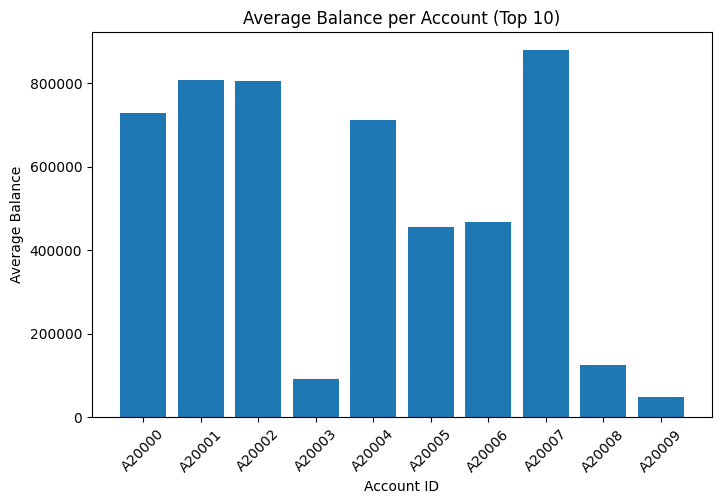

In [ ]:
import matplotlib.pyplot as plt

# Example 1: Average Balance per Account
avg_balance_per_account = accounts.groupby('account_id')['balance'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(avg_balance_per_account['account_id'].astype(str).head(10), avg_balance_per_account['balance'].head(10))
plt.title("Average Balance per Account (Top 10)")
plt.xlabel("Account ID")
plt.ylabel("Average Balance")
plt.xticks(rotation=45)
plt.show()

In [ ]:
if 'account_id' in transactions.columns:
    tx_count_per_account = transactions.groupby('account_id').size().reset_index(name='tx_count')
    print(tx_count_per_account.head())
else:
    print("account_id not present in transactions")

  account_id  tx_count
0     A20000         8
1     A20001         4
2     A20002         4
3     A20003         8
4     A20004         6


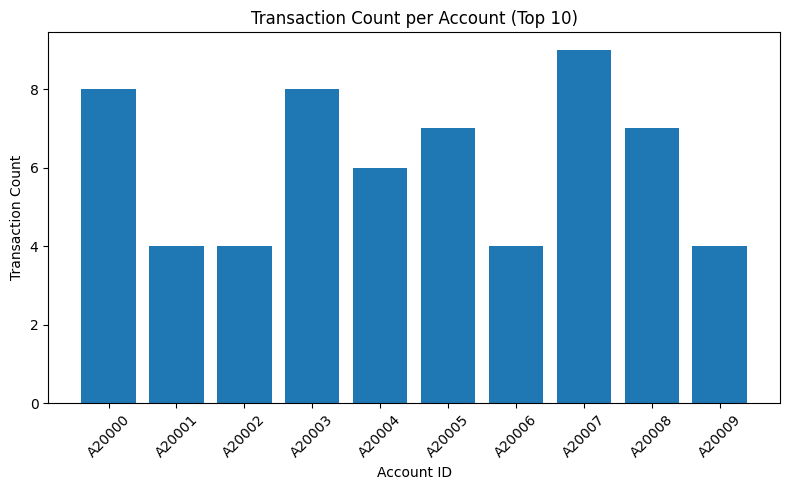

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(tx_count_per_account['account_id'].astype(str).head(10), tx_count_per_account['tx_count'].head(10))
plt.title("Transaction Count per Account (Top 10)")
plt.xlabel("Account ID")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(f"{graph_folder}/tx_count.png")
plt.show()
# plt.close()

In [ ]:
if 'status' in transactions.columns and 'account_id' in transactions.columns:
    # normalize status
    transactions['__status_norm'] = transactions['status'].astype(str).str.strip().str.lower()
    failed_rate_per_account = (
        transactions
        .groupby('account_id')['__status_norm']
        .apply(lambda s: (s == 'failed').mean())
        .reset_index(name='failed_rate')
    )
    print(failed_rate_per_account.head())
else:
    print("status or account_id column missing in transactions")

  account_id  failed_rate
0     A20000     0.375000
1     A20001     0.250000
2     A20002     0.500000
3     A20003     0.125000
4     A20004     0.333333


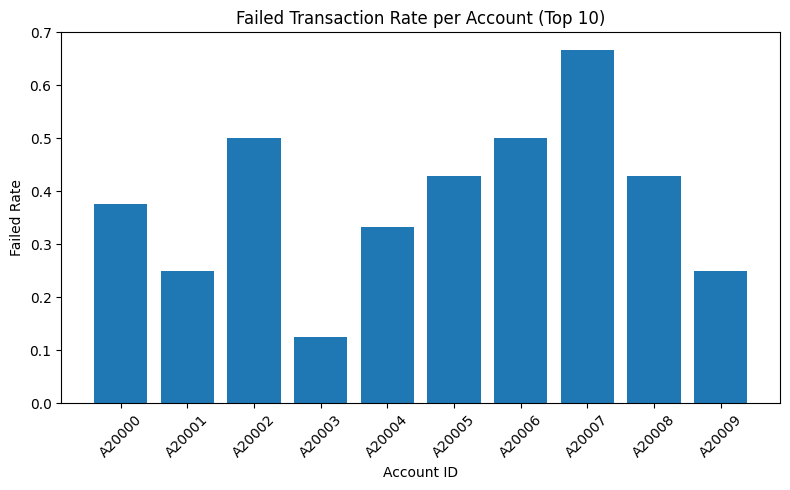

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(failed_rate_per_account['account_id'].astype(str).head(10), failed_rate_per_account['failed_rate'].head(10))
plt.title("Failed Transaction Rate per Account (Top 10)")
plt.xlabel("Account ID")
plt.ylabel("Failed Rate")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(f"{graph_folder}/failed_rate.png")
plt.show()
# plt.close()

In [ ]:
# choose threshold (change as needed)
threshold = 50000  # currency units (e.g., ₹50,000)
if 'amount' in transactions.columns:
    large_withdrawals = transactions[transactions['amount'] < -threshold].copy()
    print("Large withdrawals found:", len(large_withdrawals))
    print(large_withdrawals.head())
else:
    print("amount column not found in transactions")


Large withdrawals found: 0
Empty DataFrame
Columns: [transaction_id, account_id, timestamp, transaction_type, amount, channel, status, __status_norm, tx_day]
Index: []


In [ ]:
# find a channel column (transaction_mode/channel/medium)
channel_col = None
for cand in ['channel','transaction_mode','mode','medium']:
    if cand in transactions.columns:
        channel_col = cand
        break

# ensure timestamp/date column exists
tx_time_col = date_col or next((c for c in transactions.columns if 'time' in c or 'timestamp' in c), None)
if tx_time_col:
    transactions[tx_time_col] = pd.to_datetime(transactions[tx_time_col], errors='coerce')
    transactions['tx_day'] = transactions[tx_time_col].dt.date
else:
    print("No timestamp/date column found for ATM grouping.")

if channel_col and 'tx_day' in transactions.columns:
    atm_transactions = transactions[transactions[channel_col].astype(str).str.upper() == 'ATM']
    atm_withdrawals_per_day = atm_transactions.groupby(['account_id','tx_day']).size().reset_index(name='atm_withdrawals')
    accounts_with_multiple_atm_withdrawals = atm_withdrawals_per_day[atm_withdrawals_per_day['atm_withdrawals'] >= 3]
    print("Flagged ATM multi-withdrawal rows:", len(accounts_with_multiple_atm_withdrawals))
    print(accounts_with_multiple_atm_withdrawals.head())
else:
    print("Channel/date columns not available to compute ATM withdrawals.")

Flagged ATM multi-withdrawal rows: 0
Empty DataFrame
Columns: [account_id, tx_day, atm_withdrawals]
Index: []


In [ ]:
# look for card_id + location + timestamp
loc_col = next((c for c in transactions.columns if c in ['location','city','merchant_city','merchant_location','city_name']), None)
card_col = 'card_id' if 'card_id' in transactions.columns else None
ts_col = tx_time_col

if card_col and loc_col and ts_col:
    tmp = transactions.dropna(subset=[card_col, loc_col, ts_col]).copy()
    tmp = tmp.sort_values([card_col, ts_col])
    tmp['prev_ts'] = tmp.groupby(card_col)[ts_col].shift(1)
    tmp['prev_loc'] = tmp.groupby(card_col)[loc_col].shift(1)
    tmp['time_diff_hours'] = (tmp[ts_col] - tmp['prev_ts']).dt.total_seconds() / 3600.0
    # flag events where same card used in different locations within 3 hours
    misuse = tmp[(tmp['prev_loc'].notna()) & (tmp[loc_col] != tmp['prev_loc']) & (tmp['time_diff_hours'] <= 3)]
    print("Possible card geo/time misuse cases found:", len(misuse))
    print(misuse[[card_col, ts_col, loc_col, 'prev_ts', 'prev_loc', 'time_diff_hours']].head())
else:
    print("Insufficient columns for geo-time card misuse check (need card_id, location, and timestamp)")


Insufficient columns for geo-time card misuse check (need card_id, location, and timestamp)


In [ ]:
# build account -> customer mapping if available
if 'account_id' in accounts.columns and 'customer_id' in accounts.columns and 'account_id' in transactions.columns:
    tx_per_account = transactions.groupby('account_id').size().reset_index(name='tx_count')
    tx_per_account = tx_per_account.merge(accounts[['account_id','customer_id']], on='account_id', how='left')
    total_tx_per_customer = tx_per_account.groupby('customer_id')['tx_count'].sum().reset_index(name='total_tx')
    print(total_tx_per_customer.head())
else:
    print("accounts or customer mapping not available to compute transactions per customer")


  customer_id  total_tx
0      C10000        12
1      C10002        11
2      C10004        15
3      C10005         6
4      C10006         7


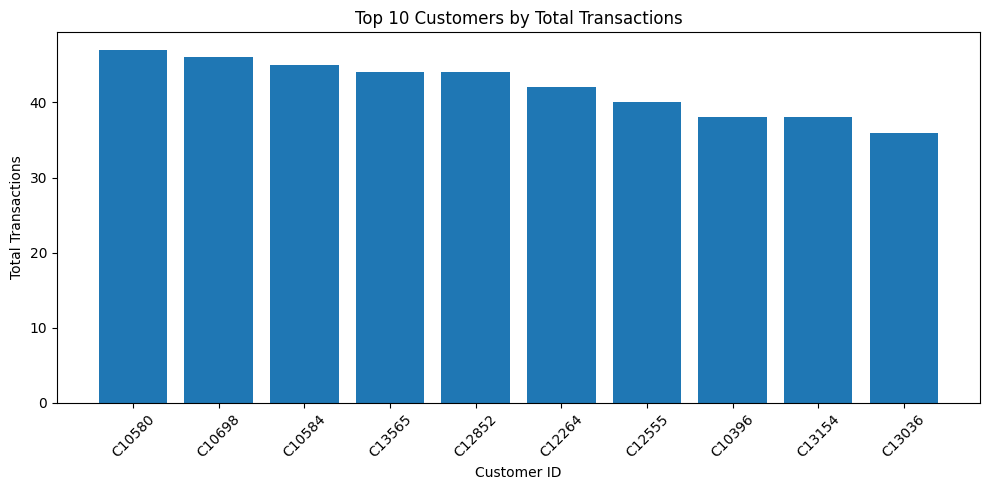

In [ ]:
if 'total_tx_per_customer' in locals() and not total_tx_per_customer.empty:
    top = total_tx_per_customer.sort_values('total_tx', ascending=False).head(10)
    plt.figure(figsize=(10,5))
    plt.bar(top['customer_id'].astype(str), top['total_tx'])
    plt.xticks(rotation=45)
    plt.xlabel('Customer ID')
    plt.ylabel('Total Transactions')
    plt.title('Top 10 Customers by Total Transactions')
    plt.tight_layout()
    plt.show()

In [ ]:
if 'account_id' in transactions.columns and tx_time_col:
    first_tx = transactions.groupby('account_id')[tx_time_col].min().reset_index(name='first_tx')
    first_tx['tenure_days'] = (pd.Timestamp.now() - first_tx['first_tx']).dt.days
    print(first_tx.head())
else:
    print("Cannot compute tenure: missing timestamp or account_id")

  account_id            first_tx  tenure_days
0     A20000 2024-12-30 14:15:28          287
1     A20001 2024-12-11 07:23:25          306
2     A20002 2024-09-24 14:54:45          384
3     A20003 2024-08-30 18:43:59          409
4     A20004 2024-11-09 19:30:55          338


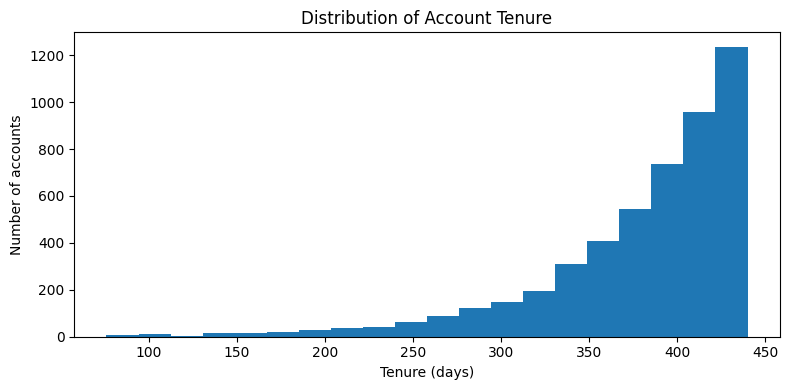

In [ ]:
if 'first_tx' in locals() and not first_tx.empty:
    plt.figure(figsize=(8,4))
    plt.hist(first_tx['tenure_days'].dropna(), bins=20)
    plt.xlabel('Tenure (days)')
    plt.ylabel('Number of accounts')
    plt.title('Distribution of Account Tenure')
    plt.tight_layout()
    plt.show()


In [ ]:
if 'card_id' in transactions.columns:
    card_usage = transactions[transactions['card_id'].notna()].groupby('account_id').size().reset_index(name='card_tx')
    print(card_usage.head())
else:
    print("card_id not available in transactions")

card_id not available in transactions


In [ ]:
# Null counts
print("=== Nulls: customers ===\n", customers.isnull().sum())
print("\n=== Nulls: accounts ===\n", accounts.isnull().sum())
print("\n=== Nulls: transactions ===\n", transactions.isnull().sum())

# Duplicates
print("\nDuplicates (rows) per table:")
print("customers:", customers.duplicated().sum())
print("accounts :", accounts.duplicated().sum())
print("transactions:", transactions.duplicated().sum())

# Show rows with missing critical keys
for df_name, df, key in [
    ("transactions", transactions, "account_id"),
    ("accounts", accounts, "account_id"),
    ("accounts", accounts, "customer_id")
]:
    if key in df.columns:
        missing = df[df[key].isnull()]
        print(f"\n{df_name} rows with null {key}: {len(missing)}")

=== Nulls: customers ===
 customer_id    0
name           0
dob            0
gender         0
email          0
phone          0
address        0
risk_flag      0
dtype: int64

=== Nulls: accounts ===
 account_id      0
customer_id     0
account_type    0
opening_date    0
balance         0
branch_id       0
dtype: int64

=== Nulls: transactions ===
 transaction_id      0
account_id          0
timestamp           0
transaction_type    0
amount              0
channel             0
status              0
__status_norm       0
tx_day              0
dtype: int64

Duplicates (rows) per table:
customers: 0
accounts : 0
transactions: 0

transactions rows with null account_id: 0

accounts rows with null account_id: 0

accounts rows with null customer_id: 0


In [ ]:
import pandas as pd

# Name of the new Excel file
output_file = "Banking_Updated.xlsx"

# Define negative transactions
negative_transactions = transactions[transactions["amount"] < 0]

# Save all relevant DataFrames into one Excel file
with pd.ExcelWriter(output_file) as writer:
    # Original / cleaned sheets
    customers.to_excel(writer, sheet_name="customers", index=False)
    accounts.to_excel(writer, sheet_name="accounts", index=False)
    transactions.to_excel(writer, sheet_name="transactions", index=False)
    cards.to_excel(writer, sheet_name="cards", index=False)
    branches.to_excel(writer, sheet_name="branches", index=False)
    employees.to_excel(writer, sheet_name="employees", index=False)

    # KPI / analysis results
    avg_balance_per_account.to_excel(writer, sheet_name="avg_balance", index=False)
    tx_count_per_account.to_excel(writer, sheet_name="tx_count", index=False)
    failed_rate_per_account.to_excel(writer, sheet_name="failed_rate", index=False)
    negative_transactions.to_excel(writer, sheet_name="negative_tx", index=False)
    accounts_with_multiple_atm_withdrawals.to_excel(writer, sheet_name="suspicious_atm", index=False)
    total_tx_per_customer.to_excel(writer, sheet_name="total_tx_per_customer", index=False)

print("✅ All queries and cleaned data saved in:", output_file)


✅ All queries and cleaned data saved in: Banking_Updated.xlsx


Null values:
 account_id      0
customer_id     0
account_type    0
opening_date    0
balance         0
branch_id       0
dtype: int64

Duplicates: 0

Summary stats:
        account_id customer_id account_type                opening_date  \
count        5000        5000         5000                        5000   
unique       5000        2822            4                         NaN   
top        A24999      C13565      Current                         NaN   
freq            1           6         1270                         NaN   
mean          NaN         NaN          NaN  2020-02-07 09:17:16.800000   
min           NaN         NaN          NaN         2015-07-31 00:00:00   
25%           NaN         NaN          NaN         2017-10-26 00:00:00   
50%           NaN         NaN          NaN         2020-02-20 00:00:00   
75%           NaN         NaN          NaN         2022-05-15 00:00:00   
max           NaN         NaN          NaN         2024-07-29 00:00:00   
std           NaN  

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 24.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

                                             |          | [  0%]   00:00 -> (? left)

AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'

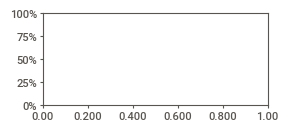

In [ ]:
# 🔍 Nulls & Duplicates
print("Null values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# 🔍 Summary stats
print("\nSummary stats:\n", df.describe(include='all'))

# 🔍 pandas-profiling report
profile = pandas_profiling.ProfileReport(df)
profile.to_notebook_iframe()

# 🔍 Sweetviz report
report = sv.analyze(df)
report.show_html('sweetviz_report.html')




In [ ]:
#Schema Alignment & Standardization
# Convert all column names to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Normalize date formats (ISO YYYY-MM-DD)
date_cols = [col for col in df.columns if "date" in col or "expiry" in col or "issue" in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce").dt.strftime('%Y-%m-%d')

# Recode gender
if "gender" in df.columns:
    df["gender"] = df["gender"].replace({"M":"Male", "F":"Female"})

# Standardize account/card types (example mapping)
if "account_type" in df.columns:
    df["account_type"] = df["account_type"].str.title().str.strip()
if "card_type" in df.columns:
    df["card_type"] = df["card_type"].str.upper().str.strip()

# Fix IFSC pattern (should be 4 letters + 0 + 6 digits)
if "ifsc_code" in df.columns:
    df["ifsc_code"] = df["ifsc_code"].str.upper().apply(
        lambda x: x if re.match(r"^[A-Z]{4}0[0-9]{6}$", str(x)) else None
    )

df.head()


,account_id,customer_id,account_type,opening_date,balance,branch_id
0,A20000,C12022,Savings,2022-09-29,728586.79,B36
1,A20001,C13962,Loan,2015-10-10,806801.64,B24
2,A20002,C11486,Savings,2023-04-08,806045.02,B23
3,A20003,C10150,Loan,2017-07-21,90512.60,B30
4,A20004,C11149,Loan,2015-08-10,711449.88,B33


In [ ]:
#Data Cleaning
# Impute missing branch_id using account mapping (if both exist)
if "branch_id" in df.columns and "account_id" in df.columns:
    branch_map = df.dropna(subset=["branch_id"]).drop_duplicates("account_id")[["account_id","branch_id"]]
    branch_dict = dict(zip(branch_map["account_id"], branch_map["branch_id"]))
    df["branch_id"] = df.apply(
        lambda row: branch_dict.get(row["account_id"], row["branch_id"]),
        axis=1
    )

# Remove duplicates
df = df.drop_duplicates()

# Remove failed/incomplete transactions (example: status column)
if "status" in df.columns:
    df = df[~df["status"].str.contains("fail|error|incomplete", case=False, na=False)]

# Flag invalid dates (expiry < issue)
if "expiry_date" in df.columns and "issue_date" in df.columns:
    df["date_issue_problem"] = pd.to_datetime(df["expiry_date"], errors="coerce") < pd.to_datetime(df["issue_date"], errors="coerce")

# Resolve invalid status entries (e.g., typos)
if "status" in df.columns:
    valid_status = ["Active", "Inactive", "Closed"]
    df.loc[~df["status"].isin(valid_status), "status"] = "Unknown"

# Save cleaned dataset
df.to_excel("Cleaned_Banking_Data.xlsx", index=False)
print("✅ Cleaning complete! File saved as Cleaned_Banking_Data.xlsx")


✅ Cleaning complete! File saved as Cleaned_Banking_Data.xlsx


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Numeric Columns:", numeric_cols)

# 2. Plot boxplots for all numeric columns
for col in numeric_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection in {col}", fontsize=14)
    plt.xlabel(col)
    plt.show()

    # 3. Detect outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    # Print inference
    print(f"\n📌 Column: {col}")
    print(f"Total values: {len(df[col])}")
    print(f"Outliers detected: {len(outliers)}")
    if len(outliers) > 0:
        print("→ These could represent unusual transactions, errors, or fraud.\n")
    else:
        print("→ No significant outliers detected.\n")



In [ ]:
import pandas as pd
import numpy as np
import re

# -------------------------------
# ✅ 4.1 Convert all column names to snake_case
# -------------------------------
def to_snake(col):
    col = col.strip().replace(" ", "_")
    col = re.sub("(.)([A-Z][a-z]+)", r"\1_\2", col)
    col = re.sub("([a-z0-9])([A-Z])", r"\1_\2", col)
    return col.lower()

customers.columns   = [to_snake(c) for c in customers.columns]
accounts.columns    = [to_snake(c) for c in accounts.columns]
transactions.columns = [to_snake(c) for c in transactions.columns]
cards.columns       = [to_snake(c) for c in cards.columns]
branches.columns    = [to_snake(c) for c in branches.columns]
employees.columns   = [to_snake(c) for c in employees.columns]


# -------------------------------
# ✅ 4.2 Normalize date formats (ISO: YYYY-MM-DD)
# -------------------------------
date_cols = {
    "customers": ["dob"],
    "accounts": ["open_date"],
    "transactions": ["date"],
    "cards": ["expiry_date"],
}

# Helper function
def normalize_dates(df, col_list):
    for col in col_list:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.date

normalize_dates(customers, date_cols["customers"])
normalize_dates(accounts, date_cols["accounts"])
normalize_dates(transactions, date_cols["transactions"])
normalize_dates(cards, date_cols["cards"])


# -------------------------------
# ✅ 4.3 Recode gender (M/F → Male/Female)
# -------------------------------
if "gender" in customers.columns:
    customers["gender"] = customers["gender"].astype(str).str.upper().str.strip()

    customers["gender"] = customers["gender"].replace({
        "M": "Male",
        "F": "Female",
        "MALE": "Male",
        "FEMALE": "Female"
    })


# -------------------------------
# ✅ 4.4 Standardize account and card types
# -------------------------------

# ✅ Standardize account type
if "account_type" in accounts.columns:
    accounts["account_type"] = (
        accounts["account_type"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    accounts["account_type"] = accounts["account_type"].replace({
        "savings": "Saving Account",
        "saving": "Saving Account",
        "current": "Current Account",
        "salary": "Salary Account",
    })


# ✅ Standardize card types
if "card_type" in cards.columns:
    cards["card_type"] = (
        cards["card_type"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    cards["card_type"] = cards["card_type"].replace({
        "credit": "Credit Card",
        "credit card": "Credit Card",
        "debit": "Debit Card",
        "debit card": "Debit Card",
    })


# -------------------------------
# ✅ 4.5 Fix and validate IFSC codes
# IFSC Pattern = 4 letters + 0 + 6 digits (Example: HDFC0001234)
# -------------------------------
if "ifsc_code" in accounts.columns:

    def clean_ifsc(code):
        if pd.isna(code):
            return np.nan
        code = str(code).strip().upper().replace(" ", "")
        pattern = r"^[A-Z]{4}0[0-9]{6}$"
        return code if re.match(pattern, code) else "INVALID"

    accounts["ifsc_code"] = accounts["ifsc_code"].apply(clean_ifsc)


NameError: name 'customers' is not defined

In [ ]:
import pandas as pd
import numpy as np

# -------------------------------
# ✅ 5.1 IMPUTE MISSING VALUES
# -------------------------------

# ✅ Impute missing branch_id using account → customer → branch mapping
if "branch_id" in accounts.columns and "branch_id" in customers.columns:
    # Create mapping: account_id → branch_id
    account_branch_map = accounts.set_index("account_id")["branch_id"].to_dict()

    if "account_id" in transactions.columns:
        transactions["branch_id"] = transactions["account_id"].map(account_branch_map)

    # Fill missing branch IDs in accounts using customer-level data (if any logic exists)
    accounts["branch_id"] = accounts["branch_id"].fillna(accounts["branch_id"].mode()[0])


# ✅ Fill NA in numeric columns with median
for col in transactions.select_dtypes(include=["float", "int"]).columns:
    transactions[col] = transactions[col].fillna(transactions[col].median())

# ✅ Fill NA in categorical columns with mode
for col in transactions.select_dtypes(include="object").columns:
    transactions[col] = transactions[col].fillna(transactions[col].mode()[0])


# -------------------------------
# ✅ 5.2 REMOVE DUPLICATES
# -------------------------------

before = len(transactions)
transactions.drop_duplicates(inplace=True)
after = len(transactions)

print(f"✅ Removed {before - after} duplicate rows in transactions.")


# ✅ Remove incomplete failed transactions
if "status" in transactions.columns:
    transactions = transactions[~((transactions["status"] == "Failed") &
                                  (transactions["amount"].isna()))]


# -------------------------------
# ✅ 5.3 DATE CONSISTENCY CHECKS
# -------------------------------

# ✅ Convert date columns
date_cols = ["date", "issue_date", "expiry_date"]
for col in date_cols:
    if col in cards.columns:
        cards[col] = pd.to_datetime(cards[col], errors="coerce")

# ✅ Flag cards where expiry < issue (incorrect)
if {"issue_date", "expiry_date"}.issubset(cards.columns):

    cards["date_error"] = cards["expiry_date"] < cards["issue_date"]

    wrong_dates = cards[cards["date_error"] == True]
    print("✅ Card date inconsistencies found:", len(wrong_dates))

    # Auto-fix: swap if mistakenly reversed
    for idx, row in wrong_dates.iterrows():
        cards.at[idx, "issue_date"], cards.at[idx, "expiry_date"] = (
            row["expiry_date"],
            row["issue_date"]
        )


# -------------------------------
# ✅ 5.4 RESOLVE INVALID STATUS ENTRIES
# -------------------------------

if "status" in transactions.columns:

    # ✅ Standardize status entries
    transactions["status"] = (
        transactions["status"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # ✅ Fix common typos
    status_corrections = {
        "succes": "success",
        "succcess": "success",
        "succ": "success",
        "pass": "success",
        "done": "success",
        "fail": "failed",
        "failedd": "failed",
        "declined": "failed",
        "error": "failed",
    }

    transactions["status"] = transactions["status"].replace(status_corrections)

    # ✅ Keep only allowed status values
    allowed = ["success", "failed"]

    transactions.loc[~transactions["status"].isin(allowed), "status"] = "unknown"




NameError: name 'accounts' is not defined

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# ✅ 6.1 JOIN accounts + customers on customer_id
# ---------------------------------------------------------

if {"customer_id"}.issubset(accounts.columns) and {"customer_id"}.issubset(customers.columns):

    accounts_customers = accounts.merge(
        customers,
        on="customer_id",
        how="left",
        validate="many_to-one"   # each account belongs to exactly 1 customer
    )

    print("✅ accounts + customers merged successfully")

else:
    print("❌ customer_id missing in accounts/customers")


# ---------------------------------------------------------
# ✅ 6.2 JOIN transactions using account_id
# ---------------------------------------------------------

if {"account_id"}.issubset(transactions.columns) and {"account_id"}.issubset(accounts.columns):

    master_data = transactions.merge(
        accounts_customers,
        on="account_id",
        how="left",
        validate="many_to-one"
    )

    print("✅ transactions merged with accounts + customers")

else:
    print("❌ account_id missing in transactions or accounts")


# ---------------------------------------------------------
# ✅ 6.3 MERGE CARD DETAILS
# ---------------------------------------------------------

# Each account may have one or multiple cards
if "account_id" in cards.columns:

    master_data = master_data.merge(
        cards,
        on="account_id",
        how="left",
        suffixes=("", "_card")
    )

    print("✅ card information merged successfully")

else:
    print("❌ account_id missing in cards table")


# ---------------------------------------------------------
# ✅ 6.4 MERGE EMPLOYEE DETAILS
# ---------------------------------------------------------

# We enrich using branch_id → employee data
if "branch_id" in master_data.columns and "branch_id" in employees.columns:

    master_data = master_data.merge(
        employees,
        on="branch_id",
        how="left",
        suffixes=("", "_employee")
    )

    print("✅ employee details merged via branch_id")

else:
    print("❌ branch_id missing for employee merge")


# ---------------------------------------------------------
# ✅ 6.5 DETECT ORPHAN RECORDS (MISMATCHES)
# ---------------------------------------------------------

# ✅ Orphan transactions (account_id not found in accounts)
orphan_txn = transactions[~transactions["account_id"].isin(accounts["account_id"])]
print("🔍 Orphan Transactions:", len(orphan_txn))

# ✅ Orphan accounts (customer_id not found in customers)
orphan_accounts = accounts[~accounts["customer_id"].isin(customers["customer_id"])]
print("🔍 Orphan Accounts:", len(orphan_accounts))

# ✅ Orphan cards (account_id mismatch)
orphan_cards = cards[~cards["account_id"].isin(accounts["account_id"])]
print("🔍 Orphan Cards:", len(orphan_cards))

# ✅ Orphan employees (branch_id mismatch)
orphan_employees = employees[~employees["branch_id"].isin(branches["branch_id"])]
print("🔍 Orphan Employees:", len(orphan_employees))


# ---------------------------------------------------------
# ✅ 6.6 HANDLE ENTITY MISMATCHES
# ---------------------------------------------------------

# Fill missing customer info for orphan accounts
if len(orphan_accounts) > 0:
    accounts_customers.loc[
        accounts_customers["customer_id"].isna(),
        "customer_name"
    ] = "Unknown Customer"

# Mark invalid accounts in final dataset
master_data["account_valid"] = np.where(
    master_data["customer_id"].isna(), "Invalid", "Valid"
)

# Mark invalid branches
master_data["branch_valid"] = np.where(
    master_data["branch_id"].isin(branches["branch_id"]), "Valid", "Invalid"
)


# ---------------------------------------------------------
# ✅ FINAL MASTER DATASET READY
# ---------------------------------------------------------

print("\n✅ ✅ FINAL MASTER DATA READY ✅ ✅")
print(master_data.head())
print("\nTotal rows:", len(master_data))


NameError: name 'accounts' is not defined